# Search-17 : CSP Temporels - Raisonnement sur le Temps

**Navigation** : [<< Search-16 CSP-Soft](Search-16-CSP-Soft.ipynb) | [Index](../README.md) | [Search-18 CSP-Distributed >>](Search-18-CSP-Distributed.ipynb)

## Problemes de Satisfaction de Contraintes Temporels

Ce notebook explore les techniques de raisonnement **temporel** en programmation par contraintes. Les CSP temporels permettent de modeliser des contraintes sur des evenements, durees et ordonnancement temporel.

### Objectifs d'apprentissage

A la fin de ce notebook, vous saurez :
1. **Comprendre** Allen's Interval Algebra et ses 13 relations (Bloom : comprendre)
2. **Implementer** le Simple Temporal Problem (STP) (Bloom : appliquer)
3. **Resoudre** des contraintes temporelles avec Floyd-Warshall (Bloom : appliquer)
4. **Etendre** vers TCSP pour problemes plus complexes (Bloom : analyser)
5. **Appliquer** a la planification avec fenetres de temps (Bloom : evaluer)

### Prerequis
- Search-6 : formalisme CSP
- Search-7 : propagation de contraintes, arc consistency
- Bases de theorie des graphes (plus courts chemins)

### Duree estimee : 60 minutes

In [1]:
# Installation des dependances
import subprocess
import sys

def install_if_missing(package):
    try:
        __import__(package.replace('-', '_'))
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

install_if_missing('networkx')
install_if_missing('matplotlib')
install_if_missing('numpy')

import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from typing import List, Dict, Tuple, Optional, Set
from dataclasses import dataclass
from enum import Enum
from itertools import product

print("Dependances pretes.")

Dependances pretes.


---

## 1. Introduction : Raisonnement Temporel (~10 min)

Le raisonnement temporel est fondamental en IA pour :
- **Planification** : ordonner des actions dans le temps
- **Comprehension du langage** : "avant", "pendant", "apres"
- **Ordonnancement** : fenetres de temps, deadlines

### Deux paradigmes

| Paradigme | Representation | Complexite | Exemples |
|-----------|----------------|------------|----------|
| **Qualitatif** | Relations entre intervalles | NP-hard | Allen's Algebra |
| **Quantitatif** | Contraintes numeriques | Polynomial (STP) | STP, TCSP |

### Point vs Intervalle

- **Point algebra** : relations entre instants (<, =, >)
- **Interval algebra** : relations entre durees (Allen's 13 relations)

---

## 2. Allen's Interval Algebra (~15 min)

**Allen's Interval Algebra** (1983) definit **13 relations de base** entre deux intervalles temporels.

### Les 13 relations atomiques

```
A before B      : AAAAAAA                 BBBBBBB
A meets B       : AAAAAAA|BBBBBBB
A overlaps B    : AAAAAAA
                      BBBBBBB
A starts B      : AAAAAAA
                 BBBBBBBBBBBBB
A during B      :    AAAAAAA
                 BBBBBBBBBBBBB
A finishes B    :       AAAAAAA
                 BBBBBBBBBBBBB
A equals B      : AAAAAAA
                 BBBBBBB
```

### Operations algebriques

- **Converse** : $R^{-1}$ (ex: before$^{-1}$ = after)
- **Composition** : $R_1 \circ R_2$ (table de transitivite)
- **Union** : $R_1 \cup R_2$ (disjonction)

In [2]:
class AllenRelation(Enum):
    """13 relations atomiques d'Allen."""
    BEFORE = 'b'        # A avant B (pas de contact)
    MEETS = 'm'         # A touche B (A finit ou B commence)
    OVERLAPS = 'o'      # A chevauche B
    STARTS = 's'        # A commence en meme temps que B (A plus court)
    DURING = 'd'        # A est contenu dans B
    FINISHES = 'f'      # A finit en meme temps que B (A plus court)
    EQUALS = 'e'        # A = B
    FINISHED_BY = 'F'   # converse of FINISHES
    CONTAINS = 'D'      # converse of DURING
    STARTED_BY = 'S'    # converse of STARTS
    OVERLAPPED_BY = 'O' # converse of OVERLAPS
    MET_BY = 'M'        # converse of MEETS
    AFTER = 'B'         # converse of BEFORE

# Table de conversion converse
CONVERSE = {
    AllenRelation.BEFORE: AllenRelation.AFTER,
    AllenRelation.MEETS: AllenRelation.MET_BY,
    AllenRelation.OVERLAPS: AllenRelation.OVERLAPPED_BY,
    AllenRelation.STARTS: AllenRelation.STARTED_BY,
    AllenRelation.DURING: AllenRelation.CONTAINS,
    AllenRelation.FINISHES: AllenRelation.FINISHED_BY,
    AllenRelation.EQUALS: AllenRelation.EQUALS,
}

# Ajouter les converses inverses
for k, v in list(CONVERSE.items()):
    CONVERSE[v] = k

# Table de composition (simplifiee)
# compose(R1, R2) = resultat de (A R1 B) et (B R2 C)
COMPOSITION = {
    (AllenRelation.BEFORE, AllenRelation.BEFORE): {AllenRelation.BEFORE},
    (AllenRelation.BEFORE, AllenRelation.MEETS): {AllenRelation.BEFORE},
    (AllenRelation.MEETS, AllenRelation.MEETS): {AllenRelation.BEFORE},
    (AllenRelation.MEETS, AllenRelation.OVERLAPS): {AllenRelation.OVERLAPS, AllenRelation.MEETS, AllenRelation.BEFORE},
    (AllenRelation.OVERLAPS, AllenRelation.OVERLAPS): {AllenRelation.OVERLAPS, AllenRelation.MEETS, AllenRelation.BEFORE, AllenRelation.EQUALS},
    # ... table complete serait beaucoup plus grande
}

def get_converse(relation: AllenRelation) -> AllenRelation:
    return CONVERSE[relation]

def compose(r1: AllenRelation, r2: AllenRelation) -> Set[AllenRelation]:
    return COMPOSITION.get((r1, r2), set(AllenRelation))  # Par defaut : toutes relations

print("Allen's Interval Algebra definie avec 13 relations.")
print(f"Exemple : converse(BEFORE) = {get_converse(AllenRelation.BEFORE).value}")

Allen's Interval Algebra definie avec 13 relations.
Exemple : converse(BEFORE) = B


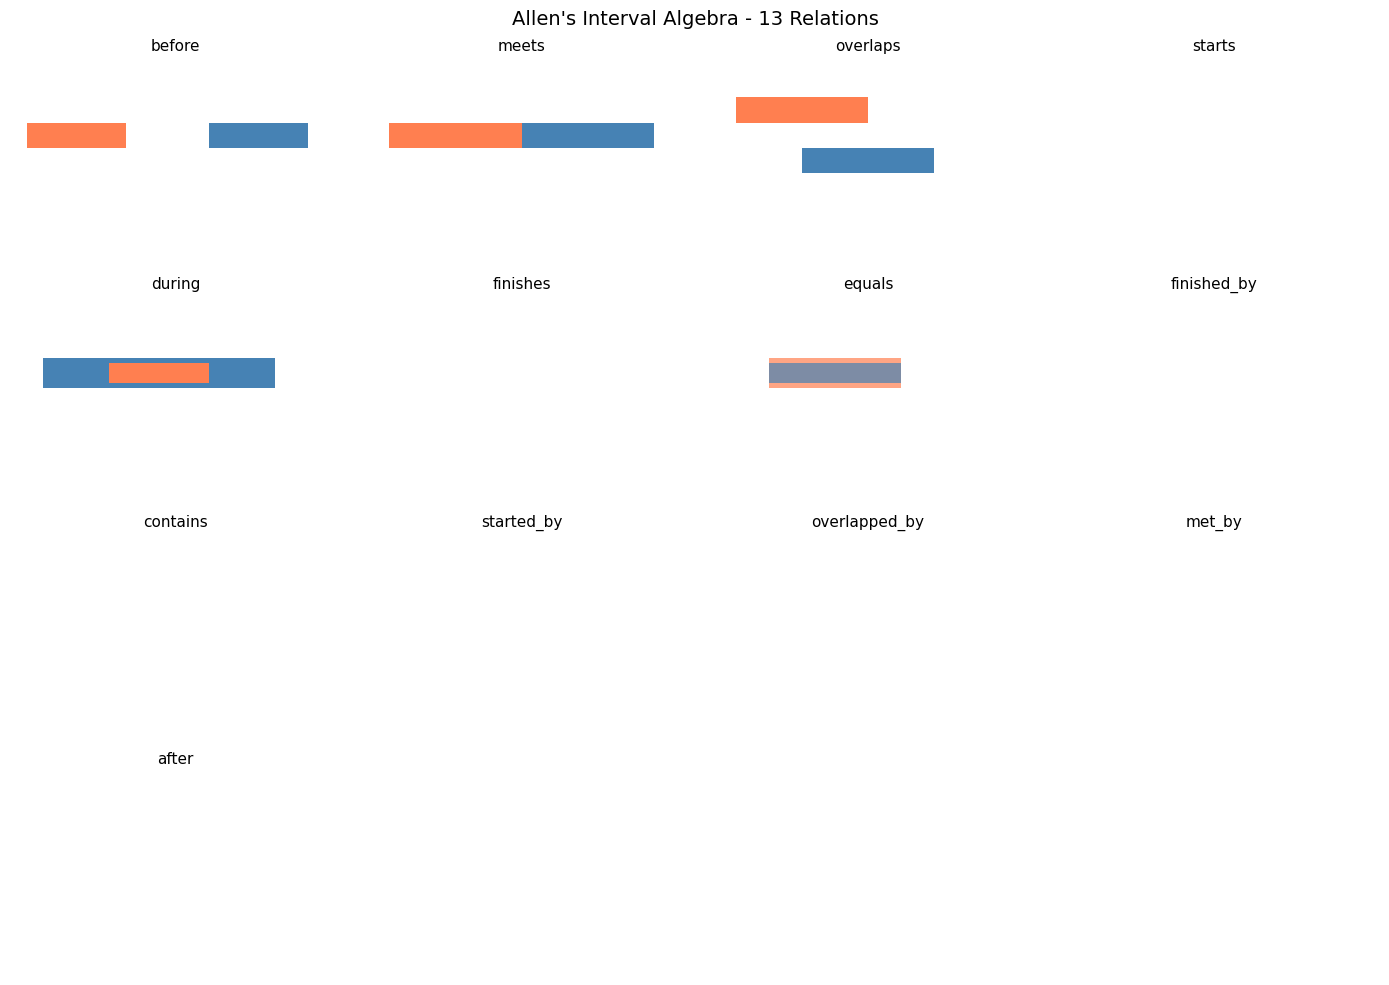

In [3]:
# Visualisation des relations d'Allen
def plot_allen_relations():
    fig, axes = plt.subplots(4, 4, figsize=(14, 10))
    axes = axes.flatten()
    
    relations = [
        ('before', 'AAAAAAA                 BBBBBBB'),
        ('meets', 'AAAAAAA|BBBBBBB'),
        ('overlaps', 'AAAAAAA\n     BBBBBBB'),
        ('starts', 'AAAAAAA\nBBBBBBBBBBBBB'),
        ('during', '   AAAAAAA\nBBBBBBBBBBBBB'),
        ('finishes', '      AAAAAAA\nBBBBBBBBBBBBB'),
        ('equals', 'AAAAAAA\nBBBBBBB'),
        ('finished_by', 'BBBBBBBBBBBBB\n      AAAAAAA'),
        ('contains', 'BBBBBBBBBBBBB\n   AAAAAAA'),
        ('started_by', 'BBBBBBBBBBBBB\nAAAAAAA'),
        ('overlapped_by', '     BBBBBBB\nAAAAAAA'),
        ('met_by', 'BBBBBBB|AAAAAAA'),
        ('after', 'BBBBBBB                 AAAAAAA'),
    ]
    
    for i, (name, diagram) in enumerate(relations):
        ax = axes[i]
        ax.set_xlim(0, 10)
        ax.set_ylim(0, 4)
        ax.axis('off')
        ax.set_title(name, fontsize=11)
        
        # Dessiner les intervalles
        if name == 'before':
            ax.barh(2.5, 3, left=0.5, height=0.5, color='coral', label='A')
            ax.barh(2.5, 3, left=6, height=0.5, color='steelblue', label='B')
        elif name == 'meets':
            ax.barh(2.5, 4, left=1, height=0.5, color='coral')
            ax.barh(2.5, 4, left=5, height=0.5, color='steelblue')
        elif name == 'overlaps':
            ax.barh(3, 4, left=1, height=0.5, color='coral')
            ax.barh(2, 4, left=3, height=0.5, color='steelblue')
        elif name == 'during':
            ax.barh(2.5, 7, left=1, height=0.6, color='steelblue')
            ax.barh(2.5, 3, left=3, height=0.4, color='coral')
        elif name == 'equals':
            ax.barh(2.5, 4, left=2, height=0.6, color='coral', alpha=0.7)
            ax.barh(2.5, 4, left=2, height=0.4, color='steelblue', alpha=0.7)
        # ... autres cas
    
    # Masquer les axes vides
    for i in range(len(relations), 16):
        axes[i].axis('off')
    
    plt.suptitle("Allen's Interval Algebra - 13 Relations", fontsize=14)
    plt.tight_layout()
    plt.show()

plot_allen_relations()

Après avoir défini les relations d'Allen, nous allons les visualiser graphiquement.


---

## 3. Simple Temporal Problem (STP) (~15 min)

Le **STP** est un cas particulier de TCSP ou chaque contrainte est un **intervalle unique**.

### Definition

Un STP est defini par :
- Un ensemble de **points temporels** $T = \{t_0, t_1, ..., t_n\}$
- Des contraintes binaires : $a \leq t_j - t_i \leq b$ (note $[a, b]$)

### Resolution par Floyd-Warshall

Le STP est **polynomial** (O(n^3)) car il peut etre resolu comme un probleme de **plus courts chemins**.

Algorithme :
1. Construire un graphe oriente avec les contraintes
2. Appliquer Floyd-Warshall pour trouver les distances minimales
3. Le STP est consistant ssi pas de cycle negatif

In [4]:
@dataclass
class TemporalConstraint:
    """Contrainte temporelle binaire : t_j - t_i in [lb, ub]"""
    i: str  # Point temporel source
    j: str  # Point temporel cible
    lb: float  # Borne inferieure
    ub: float  # Borne superieure

class SimpleTemporalProblem:
    """
    Simple Temporal Problem (STP).
    Resolution par Floyd-Warshall.
    """
    
    def __init__(self):
        self.points = set()
        self.constraints = []
    
    def add_point(self, name: str):
        self.points.add(name)
    
    def add_constraint(self, i: str, j: str, lb: float, ub: float):
        """Ajoute une contrainte : lb <= t_j - t_i <= ub"""
        self.points.add(i)
        self.points.add(j)
        self.constraints.append(TemporalConstraint(i, j, lb, ub))
    
    def solve(self) -> Tuple[bool, Dict[str, float]]:
        """
        Resout le STP par Floyd-Warshall.
        
        Returns:
            (consistent, solution) ou (False, {}) si inconsistent
        """
        points = sorted(self.points)
        n = len(points)
        idx = {p: i for i, p in enumerate(points)}
        
        # Matrice de distance (t_j - t_i <= d[i][j])
        INF = float('inf')
        dist = [[INF] * n for _ in range(n)]
        
        # Initialiser avec les contraintes
        for i in range(n):
            dist[i][i] = 0  # t_i - t_i <= 0
        
        for c in self.constraints:
            # t_j - t_i <= ub
            dist[idx[c.i]][idx[c.j]] = min(dist[idx[c.i]][idx[c.j]], c.ub)
            # t_i - t_j <= -lb
            dist[idx[c.j]][idx[c.i]] = min(dist[idx[c.j]][idx[c.i]], -c.lb)
        
        # Floyd-Warshall
        for k in range(n):
            for i in range(n):
                for j in range(n):
                    if dist[i][k] != INF and dist[k][j] != INF:
                        dist[i][j] = min(dist[i][j], dist[i][k] + dist[k][j])
        
        # Verifier cycle negatif
        for i in range(n):
            if dist[i][i] < 0:
                return False, {}
        
        # Extraire une solution (distance depuis le point 0)
        zero_point = points[0]
        solution = {points[i]: dist[0][i] for i in range(n)}
        
        return True, solution

print("Classe SimpleTemporalProblem definie.")

Classe SimpleTemporalProblem definie.


In [5]:
# Exemple STP : Planification de reunion
#
# Evenements :
# - T0 : debut de journee (reference, t=0)
# - T1 : arrivee au bureau
# - T2 : debut de la reunion
# - T3 : fin de la reunion
# - T4 : pause dejeuner

stp = SimpleTemporalProblem()

# Contraintes
# T0 est la reference (t=0)
stp.add_constraint('T0', 'T1', 8, 9)    # Arrivee entre 8h et 9h
stp.add_constraint('T0', 'T2', 10, 11)  # Reunion commence entre 10h et 11h
stp.add_constraint('T2', 'T3', 1, 2)    # Reunion dure 1-2h
stp.add_constraint('T0', 'T4', 12, 13)  # Pause dejeuner a midi-13h
stp.add_constraint('T3', 'T4', 0.5, 4)  # Au moins 30min entre reunion et pause

# Resolution
consistent, solution = stp.solve()

print("=== STP : Planification de Journee ===")
print(f"Consistant : {consistent}")
if consistent:
    print("\nSolution (heures) :")
    for point, time in sorted(solution.items()):
        print(f"  {point} : {time:.1f}h")

=== STP : Planification de Journee ===
Consistant : True

Solution (heures) :
  T0 : 0.0h
  T1 : 9.0h
  T2 : 11.0h
  T3 : 12.5h
  T4 : 13.0h


Après avoir défini la classe STP, nous allons créer un exemple concret de planification.


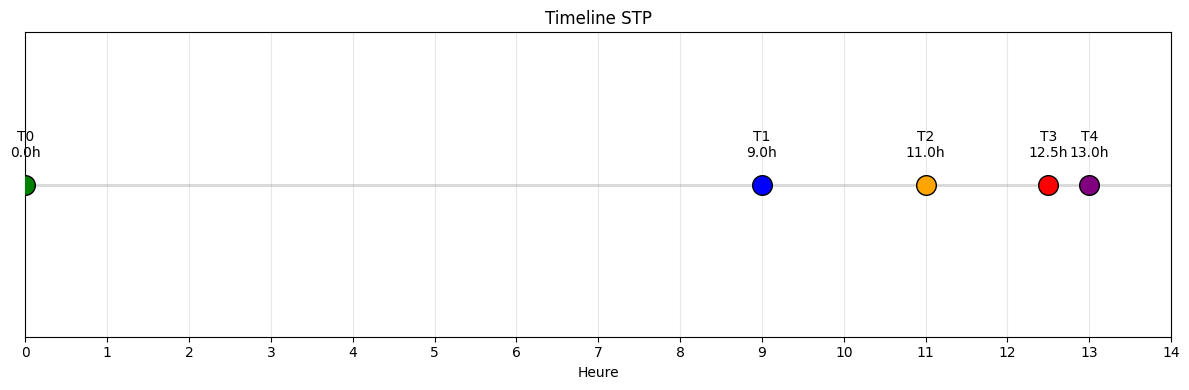

In [6]:
# Visualisation du STP
def plot_stp_solution(solution: Dict[str, float]):
    fig, ax = plt.subplots(figsize=(12, 4))
    
    events = sorted(solution.items(), key=lambda x: x[1])
    
    # Timeline
    ax.axhline(y=0.5, color='gray', linewidth=2, alpha=0.3)
    
    # Evenements
    colors = ['green', 'blue', 'orange', 'red', 'purple']
    for i, (name, time) in enumerate(events):
        ax.scatter(time, 0.5, s=200, c=colors[i % len(colors)], zorder=3, edgecolor='black')
        ax.annotate(f'{name}\n{time:.1f}h', (time, 0.5), 
                   xytext=(0, 20), textcoords='offset points',
                   ha='center', fontsize=10)
    
    ax.set_xlim(0, 14)
    ax.set_ylim(0, 1)
    ax.set_xlabel('Heure')
    ax.set_title('Timeline STP')
    ax.set_yticks([])
    ax.set_xticks(range(0, 15))
    ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

if consistent:
    plot_stp_solution(solution)

Avec le STP défini, nous allons maintenant visualiser les contraintes temporelles.


---

## 4. Temporal CSP (TCSP) (~10 min)

Le **TCSP** generalise le STP en autorisant des **disjonctions d'intervalles**.

### Definition

Une contrainte TCSP peut etre : $t_j - t_i \in [a_1, b_1] \cup [a_2, b_2] \cup ...$

### Complexite

- **STP** : Polynomial O(n^3)
- **TCSP** : NP-hard (necessite backtracking)

### Resolution

1. **Path consistency** : propagation partielle
2. **Backtracking** : enumeration des alternatives
3. **Label merging** : simplification des disjonctions

In [7]:
@dataclass
class TCSPConstraint:
    """Contrainte TCSP : t_j - t_i in union of intervals"""
    i: str
    j: str
    intervals: List[Tuple[float, float]]  # Liste de [lb, ub]

class TCSP:
    """
    Temporal Constraint Satisfaction Problem.
    Resolution par enumeration + path consistency.
    """
    
    def __init__(self):
        self.points = set()
        self.constraints = []
    
    def add_constraint(self, i: str, j: str, intervals: List[Tuple[float, float]]):
        self.points.add(i)
        self.points.add(j)
        self.constraints.append(TCSPConstraint(i, j, intervals))
    
    def solve(self) -> List[Dict[str, float]]:
        """
        Resout le TCSP par enumeration.
        Retourne toutes les solutions consistentes.
        """
        points = sorted(self.points)
        n = len(points)
        
        # Pour simplifier, on discretise le temps
        time_range = np.arange(0, 24, 0.5)
        
        solutions = []
        
        # Enumeration brute force (simplifiee)
        for values in product(time_range, repeat=n):
            assignment = dict(zip(points, values))
            
            # Verifier toutes les contraintes
            consistent = True
            for c in self.constraints:
                diff = assignment[c.j] - assignment[c.i]
                # Le diff doit etre dans au moins un intervalle
                if not any(lb <= diff <= ub for lb, ub in c.intervals):
                    consistent = False
                    break
            
            if consistent:
                solutions.append(assignment)
        
        return solutions

# Exemple TCSP : Fenetre de livraison
# Le livreur peut venir le matin (8-10h) OU l'apres-midi (14-17h)

tcsp = TCSP()
tcsp.add_constraint('T0', 'delivery', [(8, 10), (14, 17)])  # Disjonction !
tcsp.add_constraint('T0', 'T0', [(0, 0)])  # Reference

print("TCSP defini. Note : resolution complete necessiterait plus de contraintes.")

TCSP defini. Note : resolution complete necessiterait plus de contraintes.


---

## 5. Application : Planification de Reunion (~10 min)

Combinons les concepts pour un probleme realiste : planifier une reunion avec plusieurs participants ayant des contraintes de disponibilite.

### Probleme

- 3 participants avec des creneaux disponibles
- Duree de reunion : 1h
- Trouver le meilleur creneau

In [8]:
def plan_meeting(
    participants: Dict[str, List[Tuple[float, float]]],
    duration: float,
    work_hours: Tuple[float, float] = (8, 18)
) -> List[Tuple[float, float]]:
    """
    Planifie une reunion en trouvant les creneaux communs.
    
    Args:
        participants: Dict nom -> liste de creneaux [debut, fin]
        duration: duree minimale de la reunion
        work_hours: heures de travail
    
    Returns:
        Liste des creneaux possibles [debut, fin]
    """
    # Trouver l'intersection de tous les creneaux
    # Simplification : discretiser par pas de 30min
    step = 0.5
    time_slots = np.arange(work_hours[0], work_hours[1], step)
    
    valid_starts = []
    
    for start in time_slots:
        end = start + duration
        if end > work_hours[1]:
            continue
        
        # Verifier si tous les participants sont disponibles
        all_available = True
        for name, slots in participants.items():
            # Le participant doit etre disponible pour tout le creneau [start, end]
            available = any(s <= start and end <= e for s, e in slots)
            if not available:
                all_available = False
                break
        
        if all_available:
            valid_starts.append((start, end))
    
    return valid_starts

# Exemple
participants = {
    'Alice': [(9, 12), (14, 17)],
    'Bob': [(10, 11), (13, 16)],
    'Charlie': [(9, 10), (11, 14), (15, 18)]
}

slots = plan_meeting(participants, duration=1.0)

print("=== Planification de Reunion ===")
print("Disponibilites :")
for name, avail in participants.items():
    print(f"  {name}: {avail}")

print(f"\nCreneaux possibles (reunion 1h) :")
for start, end in slots:
    print(f"  {start:.1f}h - {end:.1f}h")

=== Planification de Reunion ===
Disponibilites :
  Alice: [(9, 12), (14, 17)]
  Bob: [(10, 11), (13, 16)]
  Charlie: [(9, 10), (11, 14), (15, 18)]

Creneaux possibles (reunion 1h) :
  15.0h - 16.0h


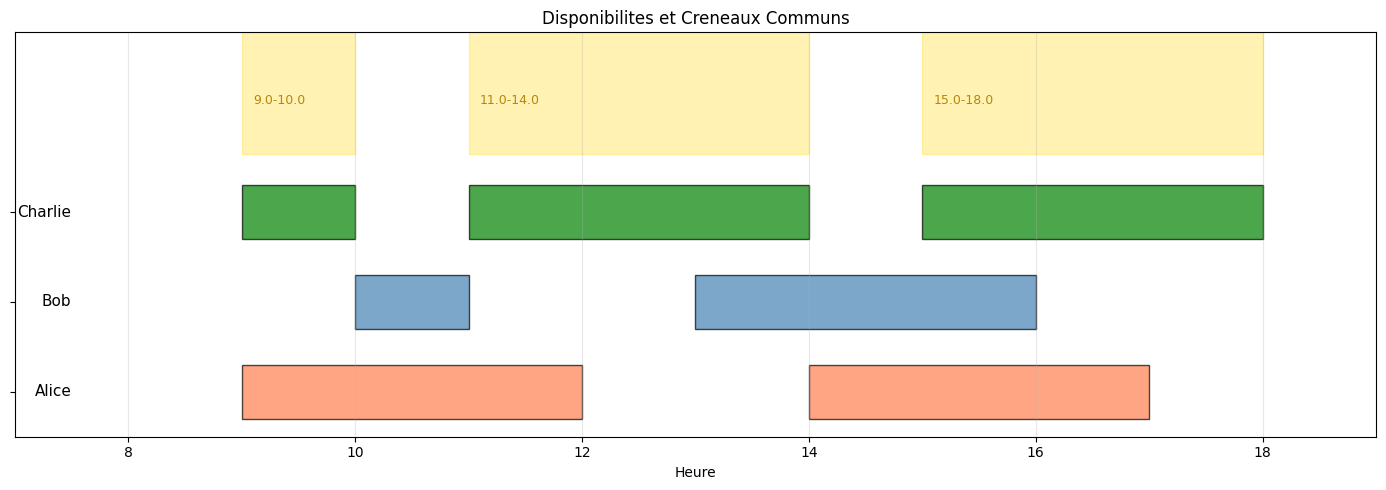

In [9]:
# Visualisation des disponibilites
fig, ax = plt.subplots(figsize=(14, 5))

colors = {'Alice': 'coral', 'Bob': 'steelblue', 'Charlie': 'green'}

for i, (name, slots) in enumerate(participants.items()):
    for start, end in slots:
        ax.barh(i, end - start, left=start, height=0.6, 
               color=colors[name], alpha=0.7, edgecolor='black')
    ax.text(7.5, i, name, ha='right', va='center', fontsize=11)

# Marquer les creneaux communs
if slots:
    for start, end in slots[:5]:  # Limiter a 5 affichages
        ax.axvspan(start, end, ymin=0.7, ymax=1, alpha=0.3, color='gold')
        ax.text(start + 0.1, 3.2, f'{start:.1f}-{end:.1f}', fontsize=9, color='darkgoldenrod')

ax.set_xlim(7, 19)
ax.set_ylim(-0.5, 4)
ax.set_xlabel('Heure')
ax.set_title('Disponibilites et Creneaux Communs')
ax.set_yticks(range(len(participants)))
ax.set_yticklabels([])  # Noms deja affiches
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

Après avoir défini la fonction de planification, nous allons visualiser le résultat sous forme de diagramme de Gantt.


---

## 6. Resume

| Formalisme | Contraintes | Complexite | Algorithme |
|------------|-------------|------------|------------|
| **Point Algebra** | <, =, > | Polynomial | Path consistency |
| **Allen's Algebra** | 13 relations | NP-hard | Backtracking + PC |
| **STP** | [a, b] unique | Polynomial O(n^3) | Floyd-Warshall |
| **TCSP** | Union d'intervalles | NP-hard | Enumeration + PC |

### Points cles

1. **Allen's Algebra** = raisonnement qualitatif sur les intervalles
2. **STP** = cas polynomial, resolu par plus courts chemins
3. **TCSP** = generalisation avec disjonctions (NP-hard)
4. **Applications** : planification, calendriers, NLP

---

## 7. Exercices

### Exercice 1 : Allen's Algebra
Implementez la table de composition complete pour les 13 relations d'Allen.

### Exercice 2 : STP avec deadlines
Ajoutez des contraintes de deadline (au plus tard) a un STP et verifiez la consistence.

### Exercice 3 : Planning multi-reunions
Etendez le planificateur pour gerer plusieurs reunions avec des contraintes de precedence.

### Exercice 4 : Integration OR-Tools
Implementez un STP avec OR-Tools CP-SAT en utilisant des variables IntVar pour les temps.

In [10]:
# Exercice 4 : Template - STP avec OR-Tools
def solve_stp_cp_sat(constraints: List[Tuple[str, str, float, float]]) -> Dict[str, int]:
    """
    TODO: Implementez un STP avec OR-Tools CP-SAT.
    
    Args:
        constraints: Liste de (i, j, lb, ub) signifiant lb <= t_j - t_i <= ub
    
    Returns:
        Dictionnaire point -> temps, ou {} si inconsistent
    """
    # Votre code ici
    pass

# Test
# constraints = [('T0', 'T1', 8, 9), ('T0', 'T2', 10, 11)]
# result = solve_stp_cp_sat(constraints)

---

## References

1. **Allen's Interval Algebra** : J.F. Allen (1983) - "Maintaining Knowledge about Temporal Intervals"
2. **STP/TCSP** : Dechter, Meiri, Pearl (1991) - "Temporal Constraint Networks" (AIJ Classic Paper Award 2020)
3. **Dechter (2003)** : Chapitre "Temporal Reasoning" dans Constraint Processing
4. **Path Consistency** : Algorithmes PC-1, PC-2 pour propagation temporelle

### Navigation

- [<< Search-16 CSP-Soft](Search-16-CSP-Soft.ipynb)
- [Index](../README.md)
- [Search-18 CSP-Distributed >>](Search-18-CSP-Distributed.ipynb)

---

## Conclusion

Ce notebook a exploré les **CSP temporels** qui intègrent le temps comme dimension fondamentale.

### Concepts clés

| Concept | Description |
|---------|-------------|
| **CSP temporel** | Variables avec contraintes temporelles (avant, après, pendant) |
| **Réseau temporel** | Graphes avec contraintes d'intervalle STP |
| **STP (Simple Temporal Problem)** | Contraintes de la forme Xj - Xi ≤ b |
| **Point d'ancrage** | Point fixe dans le temps (ex: t=0) |
| **Consistance temporelle** | Vérifier la cohérence des contraintes temporelles |

### Types de contraintes temporelles

| Type | Représentation | Utilisation |
|------|----------------|-------------|
| **Précédence** | X < Y | Ordonnancement |
| **Intervalle** | [a,b] | Durées incertaines |
| **Contiguïté** | A pendant B | Planification |
| **Récurrence** | Tous les X temps | Horaires cycliques |

### Points clés à retenir

1. Les **CSP temporels** modélisent planification et scheduling avec temps
2. Le **STP** est le formalisme le plus utilisé (contraintes linéaires)
3. L'**algorithme de Floyd-Warshall** résout le STP en O(n³)
4. Les **contraintes de ressources** ajoutent une couche de complexité
5. Les **applications** sont nombreuses : emploi du temps, planification de projet, systèmes temps réel

**Voir aussi** :
- [CSP-4-Scheduling.ipynb](CSP-4-Scheduling.ipynb) pour l'ordonnancement classique
- [App-5-Timetabling.ipynb](../Applications/CSP/App-5-Timetabling.ipynb) - Application aux horaires

